In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv(r"C:\Users\mayank raj\Downloads\BlinkIT-Grocery-Data.csv")
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [5]:
df.shape

(8523, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Data Cleaning

In [12]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [15]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF': 'Low Fat',
                                                         'low fat':'Low Fat',
                                                         'reg':'Regular'})
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

## KPI's Requirements

In [17]:
#Total Sales
total_sales = df['Sales'].sum()
#Average Sales
average_sales = df['Sales'].mean()
#No of items sold
no_of_items_sold = df['Sales'].count()
#Average Rating
average_rating = df['Rating'].mean()

print(f"Total Sales : ${total_sales:,.0f}")
print(f"Average Sales : ${average_sales:,.1f}")
print(f"No of items sold : {no_of_items_sold:,.0f}")
print(f"Average Rating : {average_rating:,.1f}")

Total Sales : $1,201,681
Average Sales : $141.0
No of items sold : 8,523
Average Rating : 4.0


## Charts Requirements

#### Total Sales By Fat content


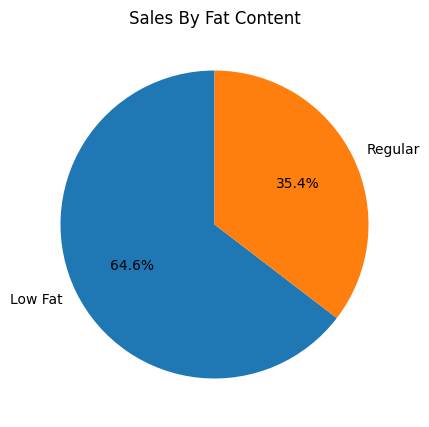

In [24]:
sales_by_fat_content = df.groupby('Item Fat Content')['Sales'].sum()

plt.figure(figsize=(5,5))
plt.pie(sales_by_fat_content, 
        labels=sales_by_fat_content.index,
        autopct = '%.1f%%',
        startangle =90
       )
plt.title('Sales By Fat Content')
plt.show()


#### Total Sales By Item Type

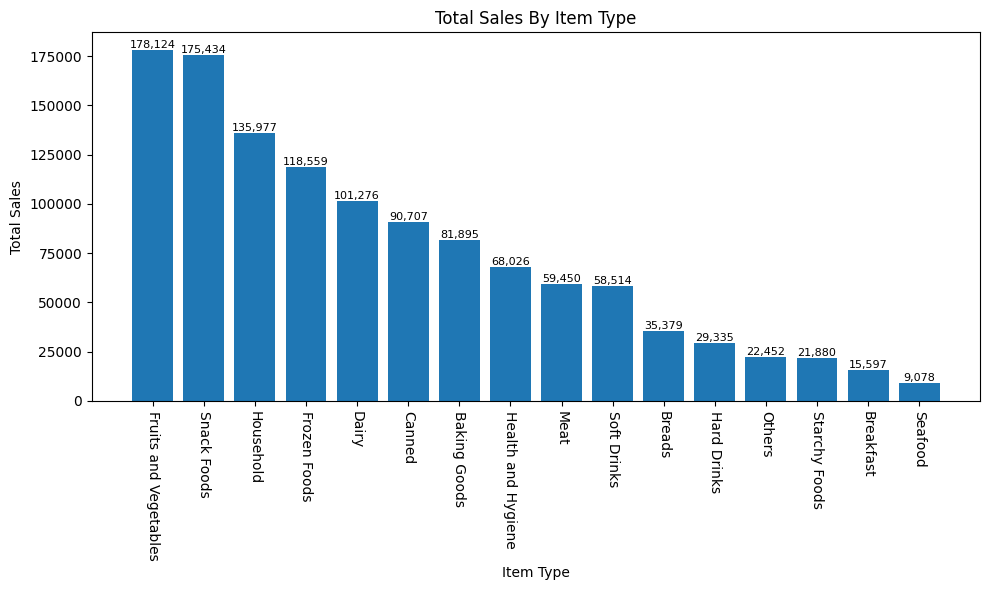

In [28]:
sales_by_item_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(sales_by_item_type.index, sales_by_item_type.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2, bar.get_height(),
        f'{bar.get_height():,.0f}' , ha='center', va = 'bottom', fontsize=8
    )

plt.title('Total Sales By Item Type')
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.xticks(rotation= -90)
plt.tight_layout()
plt.show()

#### Fat Content By Outlet Type For Total Sales

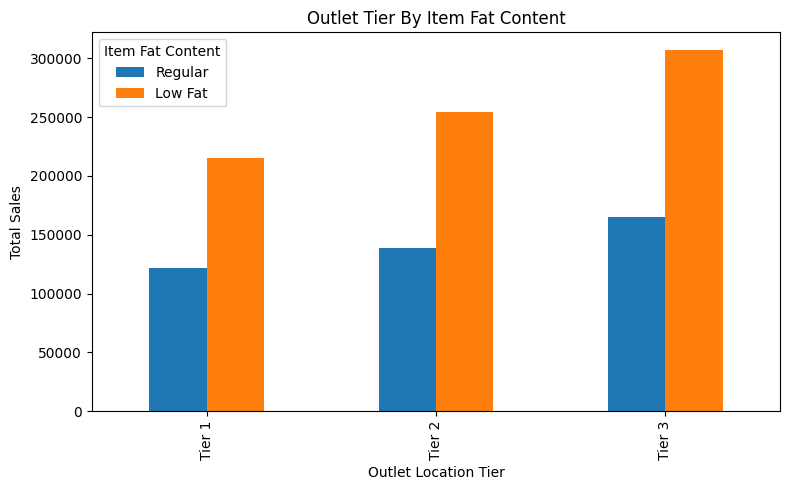

In [29]:
data = df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
data = data[['Regular','Low Fat']]

chart = data.plot(kind='bar', figsize=(8,5), title ='Outlet Tier By Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title = 'Item Fat Content')
plt.tight_layout()
plt.show()

In [32]:
data1 = df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
data1.head()

Item Fat Content,Low Fat,Regular
Outlet Location Type,,
Tier 1,215047.9126,121349.8994
Tier 2,254464.7794,138685.8682
Tier 3,306806.9964,165326.0368


### Total Sales by Outlet Establishment

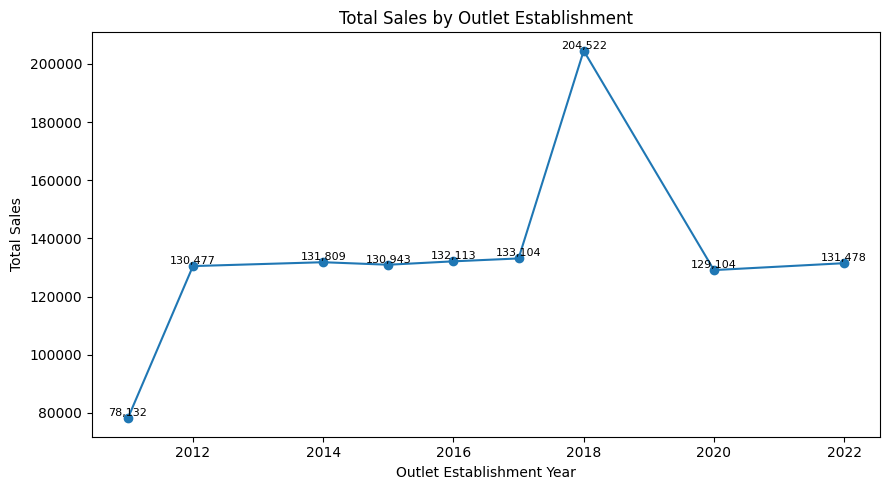

In [34]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Total Sales by Outlet Establishment')

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x,y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8 )

plt.tight_layout()
plt.show()

### Sales By Outlet Size

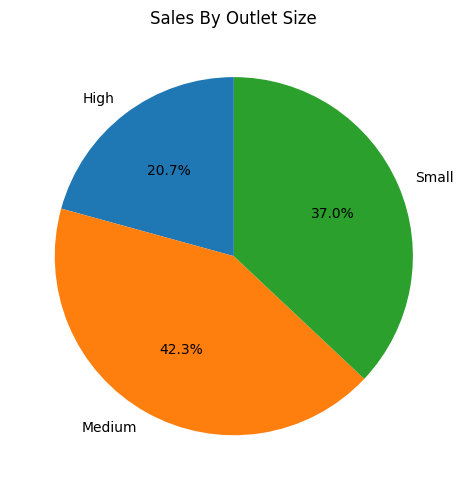

In [38]:
sales_by_size= df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(5,5))
plt.pie(sales_by_size,
        labels=sales_by_size.index,
        autopct='%1.1f%%',
        startangle=90
       )
plt.title('Sales By Outlet Size')
plt.tight_layout()
plt.show()

### Sales By Outlet Location

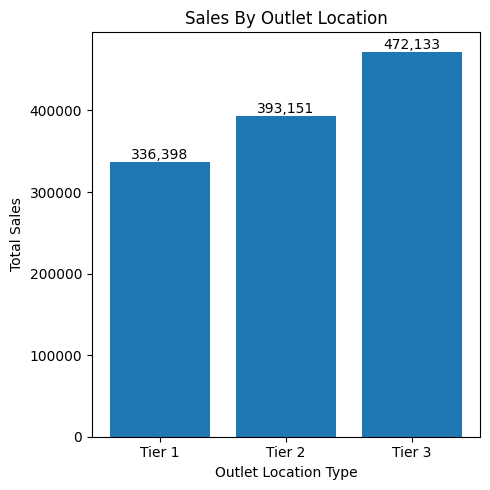

In [42]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().sort_index()

plt.figure(figsize=(5,5))

bars = plt.bar(sales_by_location.index,sales_by_location.values)

for bar in bars :
    plt.text(
        bar.get_x() + bar.get_width()/2, bar.get_height(),
        f'{bar.get_height():,.0f}', ha='center', va='bottom'
    )

plt.title('Sales By Outlet Location')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()
